In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, IterativeImputer, KNNImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

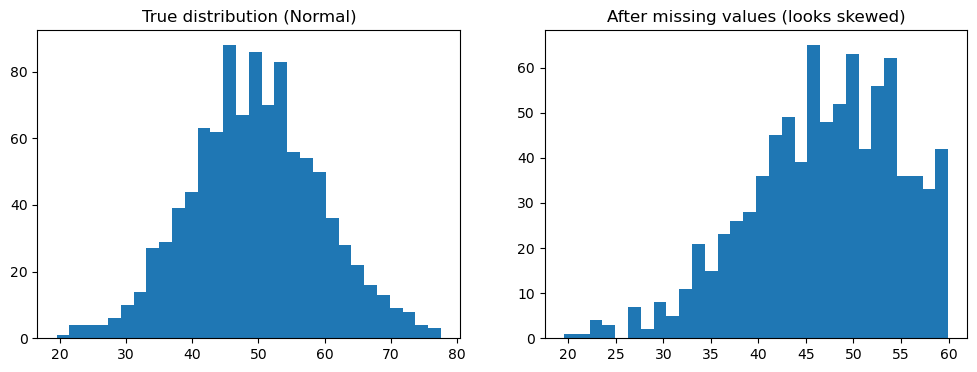

In [16]:
# example for how data looks skewed with missing values in the normal distribution without skewness
np.random.seed(0)
data = np.random.normal(loc=50, scale=10, size=1000)

biased = data.copy()
biased[biased > 60] = np.nan   # remove high values

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.hist(data, bins=30)
plt.title("True distribution (Normal)")

plt.subplot(1,2,2)
plt.hist(biased[~np.isnan(biased)], bins=30)
plt.title("After missing values (looks skewed)")

plt.show()

In [17]:
def regression_imputer(df):
    df_imputed = df.copy()
    missing_cols = df.columns[df.isnull().any()]
        
    for col in missing_cols:
        train_data = df[df[col].notna()]
        test_data  = df[df[col].isna()]
        other_cols = [c for c in df.columns if c != col]
            
        X_train = train_data[other_cols]
        y_train = train_data[col]
        X_test  = test_data[other_cols]
            
        model = LinearRegression()
        model.fit(X_train, y_train)
        df_imputed.loc[df[col].isna(), col] = model.predict(X_test)
        
    return df_imputed

In [18]:
def bias_shift_analysis(true_df, missing_df, imputed_data, target_col='Feature_B'):
    
    missing_mask = missing_df[target_col].isna()
    missing_idx  = missing_df.index[missing_mask]

    # True statistics
    true_mean_whole   = true_df[target_col].mean()
    true_std_whole    = true_df[target_col].std()
    true_mean_missing = true_df.loc[missing_idx, target_col].mean()
    true_std_missing  = true_df.loc[missing_idx, target_col].std()

    bias_records = []

    for name, df_res in imputed_data.items():
        
        imp_mean_whole   = df_res[target_col].mean()
        imp_std_whole    = df_res[target_col].std()
        imp_mean_missing = df_res.loc[missing_idx, target_col].mean()
        imp_std_missing  = df_res.loc[missing_idx, target_col].std()

        bias_records.append({
            'Imputer'              : name,

            # Whole data
            'Mean Bias (Whole)'    : imp_mean_whole - true_mean_whole,
            'Std Shift (Whole)'    : imp_std_whole - true_std_whole,

            # Missing region only
            'Mean Bias (Missing)'  : imp_mean_missing - true_mean_missing,
            'Std Shift (Missing)'  : imp_std_missing - true_std_missing,
        })

    bias_df = pd.DataFrame(bias_records).set_index('Imputer')

    return bias_df.round(4)

In [19]:
# Compares multiple imputation methods and returns results + visual plots.

def evaluate_imputations(true_df, missing_df, target_col='Feature_B'):
    missing_mask = missing_df[target_col].isna()
    missing_idx = missing_df.index[missing_mask]
    
    # 1. Define Imputers
    imputers = {
        'Mean': SimpleImputer(strategy='mean'),
        'Median': SimpleImputer(strategy='median'),
        'KNN (k=3)': KNNImputer(n_neighbors=3),
        'KNN (k=5)': KNNImputer(n_neighbors=5),
        'KNN (k=10)': KNNImputer(n_neighbors=10),
        'MICE (Iterative)': IterativeImputer(random_state=42),
        'MICE (RandomForestRegressor)': IterativeImputer(random_state=42, 
                                                         estimator=RandomForestRegressor(
                                                                                         n_estimators=100,
                                                                                         random_state=42
                                                                                         ),)
        # regression imputer called at the end
    }
    
    results = {}
    imputed_data = {}

    # 2. Process each imputer
    for name, imp in imputers.items():
        # Fit and transform
        arr = imp.fit_transform(missing_df)
        df_res = pd.DataFrame(arr, columns=missing_df.columns, index=missing_df.index)
        imputed_data[name] = df_res
        
        # Calculate RMSE specifically on the values we hid
        y_true = true_df.loc[missing_idx, target_col]
        y_pred = df_res.loc[missing_idx, target_col]
        results[name] = np.sqrt(mean_squared_error(y_true, y_pred))

    # regression imputer
    df_reg = regression_imputer(missing_df)
    imputed_data['Regression'] = df_reg
    y_true = true_df.loc[missing_idx, target_col]
    y_pred = df_reg.loc[missing_idx, target_col]
    results['Regression'] = np.sqrt(mean_squared_error(y_true, y_pred))
    
    # # 3. Plotting Logic
    # fig, axes = plt.subplots(4, 2, figsize=(15, 20))
    # axes = axes.flatten()
    
    # for i, (name, df_res) in enumerate(imputed_data.items()):
    #     ax = axes[i]
    #     # Background: Observed data
    #     ax.scatter(true_df.loc[~missing_mask, 'Feature_A'], true_df.loc[~missing_mask, target_col], 
    #                c='lightgray', alpha=0.4, label='Observed')
    #     # Truth: What was hidden
    #     ax.scatter(true_df.loc[missing_mask, 'Feature_A'], true_df.loc[missing_mask, target_col], 
    #                c='red', marker='x', alpha=0.5, label='Truth')
    #     # Imputed: The "Guesstimate"
    #     ax.scatter(df_res.loc[missing_idx, 'Feature_A'], df_res.loc[missing_idx, target_col], 
    #                c='blue', s=40, edgecolors='k', label='Imputed')
        
    #     ax.set_title(f"{name} (RMSE: {results[name]:.4f})")
    #     ax.legend(fontsize=8)
    
    # plt.tight_layout()
    # plt.show()

    # 4. Calculating the bias shift to check overall distribution 
    bias_df = bias_shift_analysis(true_df, missing_df, imputed_data, target_col)

    return pd.Series(results).sort_values(), bias_df

In [20]:
"""
MCAR data
"""

'\nMCAR data\n'

In [21]:
# Generate Linear Data
np.random.seed(42)

n = 1000
# 1000 evenly spaced numbers from 0 to 100
x = np.linspace(0, 100, n)
# y = 2x + 5 + noise
y = 2 * x + 5 + np.random.normal(0, 10, n)
df_linear = pd.DataFrame({'Feature_A': x, 'Feature_B': y})

# Punch holes (20% missing)
perc_missing = round(n  * 0.2)
df_linear_miss = df_linear.copy()
df_linear_miss.iloc[np.random.choice(n, perc_missing , replace=False), 1] = np.nan

linear_performance, bias_df = evaluate_imputations(df_linear, df_linear_miss)
print("Linear Performance Ranking:\n", linear_performance)
print(bias_df.round(4).to_string())

Linear Performance Ranking:
 Regression                      10.729887
MICE (Iterative)                10.730154
KNN (k=10)                      11.107136
KNN (k=5)                       11.248337
KNN (k=3)                       11.979236
MICE (RandomForestRegressor)    12.713614
Mean                            61.954054
Median                          62.077467
dtype: float64
                              Mean Bias (Whole)  Std Shift (Whole)  Mean Bias (Missing)  Std Shift (Missing)
Imputer                                                                                                     
Mean                                    -0.5275            -6.9168              -2.6376             -62.0532
Median                                  -0.9437            -6.9101              -4.7185             -62.0532
KNN (k=3)                               -0.1703            -0.3929              -0.8517              -1.8727
KNN (k=5)                               -0.1447            -0.4572         

In [22]:
# Generate Non-Linear Data (Sine + Quadratic)
x_nl = np.linspace(0, 10, n)
# y = x square + 10 sin(x) + noise
y_nl = (x_nl**2) + (10 * np.sin(x_nl)) + np.random.normal(0, 2, n)
df_nonlinear = pd.DataFrame({'Feature_A': x_nl, 'Feature_B': y_nl})

# Punch holes (20% missing)
df_nonlinear_miss = df_nonlinear.copy()
df_nonlinear_miss.iloc[np.random.choice(n, perc_missing, replace=False), 1] = np.nan

nonlinear_performance, bias_df_nl = evaluate_imputations(df_nonlinear, df_nonlinear_miss)
print("Non-Linear Performance Ranking:\n", nonlinear_performance)
print(bias_df_nl.round(4).to_string())

Non-Linear Performance Ranking:
 KNN (k=10)                       2.261544
KNN (k=5)                        2.366420
KNN (k=3)                        2.570203
MICE (RandomForestRegressor)     2.696767
Regression                      12.043219
MICE (Iterative)                12.043259
Mean                            32.406408
Median                          38.385294
dtype: float64
                              Mean Bias (Whole)  Std Shift (Whole)  Mean Bias (Missing)  Std Shift (Missing)
Imputer                                                                                                     
Mean                                    -0.3316            -3.6030              -1.6581             -32.4452
Median                                  -4.1280            -2.5680             -20.6399             -32.4452
KNN (k=3)                               -0.0448            -0.0596              -0.2239              -0.2781
KNN (k=5)                               -0.0264            -0.0687     

In [23]:
"""
repeating the exercise for MAR data
"""

'\nrepeating the exercise for MAR data\n'

In [24]:
np.random.seed(42)
n = 1000

# Generate observed variable
age = np.random.normal(40, 10, n)

# Generate target variable
income = 30000 + age * 1000 + np.random.normal(0, 5000, n)

df = pd.DataFrame({"Feature_A": age, "Feature_B": income})

# Create MAR missingness in Income depending on Age
prob_missing = 1 / (1 + np.exp(-(age - 40) / 5))  # logistic function
missing_mask = np.random.rand(n) < prob_missing

df_mar = df.copy()
df_mar.loc[missing_mask, "Feature_B"] = np.nan

MAR_linear_performance, MAR_bias_df = evaluate_imputations(df, df_mar)
print("MAR - Linear Performance Ranking:\n", MAR_linear_performance)
print(MAR_bias_df.round(4).to_string())

MAR - Linear Performance Ranking:
 MICE (Iterative)                 5052.276381
Regression                       5052.476429
KNN (k=5)                        5778.443465
KNN (k=10)                       6015.808294
KNN (k=3)                        6028.306446
MICE (RandomForestRegressor)     6195.168183
Median                          14376.429360
Mean                            14535.998548
dtype: float64
                              Mean Bias (Whole)  Std Shift (Whole)  Mean Bias (Missing)  Std Shift (Missing)
Imputer                                                                                                     
Mean                                 -5372.0640         -4437.5879          -10808.9819           -9728.9059
Median                               -5264.9300         -4436.6754          -10593.4205           -9728.9059
KNN (k=3)                              114.4836          -705.6317             230.3493           -1829.7474
KNN (k=5)                              -20.65

In [25]:
# NON-LINEAR relationship
income_nl = 20000 + 50*(age**2) + np.random.normal(0, 5000, n)
df = pd.DataFrame({"Feature_A": age, "Feature_B": income_nl})

df_mar = df.copy()
df_mar.loc[missing_mask, "Feature_B"] = np.nan

MAR_nl_performance, MAR_nl_bias_df = evaluate_imputations(df, df_mar)
print("MAR - Linear Performance Ranking:\n", MAR_nl_performance)
print(MAR_nl_bias_df.round(4).to_string())

MAR - Linear Performance Ranking:
 MICE (RandomForestRegressor)     9669.357577
KNN (k=3)                       11182.459403
KNN (k=5)                       12983.149614
Regression                      13776.434161
MICE (Iterative)                13781.593053
KNN (k=10)                      16729.380022
Mean                            60636.946213
Median                          62666.753922
dtype: float64
                              Mean Bias (Whole)  Std Shift (Whole)  Mean Bias (Missing)  Std Shift (Missing)
Imputer                                                                                                     
Mean                                -23255.9938        -21321.4567          -46792.7440          -38604.1047
Median                              -24549.2026        -21278.1501          -49394.7739          -38604.1047
KNN (k=3)                            -1194.3151         -3039.1074           -2403.0484           -5151.3657
KNN (k=5)                            -1716.71